In [2]:
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time

from jwst import datamodels

from tqdm.auto import tqdm

from scipy import interpolate

In [3]:
import os
os.environ['STPSF_PATH'] = os.path.expanduser('~/.cache/stpsf-data')

import stpsf

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [4]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')  # the ra and dec would have a delta in an inference loop so is different each time
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

The below should be replaced with ``stpsf.setup_sim_to_match_file(str(n6791fits[0]))`` once that works

In [5]:
nrs = stpsf.NIRSpec()
nrs.detector = dm0.meta.instrument.detector
nrs.filter = dm0.meta.instrument.filter
nrs.disperser = dm0.meta.instrument.grating

xdet, ydet = swcs.transform('detector', 'sca', *np.indices(slit.data.shape)[::-1])
nrs.detector_position = (np.mean(xdet), np.mean(ydet))

nrs.load_wss_opd_by_date(Time(dm0.meta.exposure.mid_time, format='mjd'))

nrs.image_mask = 'Single MSA open shutter'

iterating query, tdelta=3.0

MAST OPD query around UTC: 60136.5904089294
                        MJD: 60136.5904089294

OPD immediately preceding the given datetime:
	URI:	 mast:JWST/product/R2023071203-NRCA3_FP1-1.fits
	Date (MJD):	 60136.5363
	Delta time:	 -0.0542 days

OPD immediately following the given datetime:
	URI:	 mast:JWST/product/R2023071403-NRCA3_FP1-1.fits
	Date (MJD):	 60138.8979
	Delta time:	 2.3075 days
User requested choosing OPD time closest in time to 60136.5904089294, which is R2023071203-NRCA3_FP1-1.fits, delta time -0.054 days
Importing and format-converting OPD from /home/erik/.cache/stpsf-data/MAST_JWST_WSS_OPDs/R2023071203-NRCA3_FP1-1.fits
Backing out SI WFE and OTE field dependence at the WF sensing field point (NRCA3_FP1)


In [6]:
msa_slit_width = 0.2 #u.arcsec
msa_slit_height = 0.46 #u.arcsec

offset0_x = slit.source_xpos*msa_slit_width
offset0_y = slit.source_ypos*msa_slit_height

nrs.options.update({'source_offset_x': offset0_x, 
                    'source_offset_y': offset0_y})

# Make data

In [7]:
n = 1024
path = Path('psfarrs.npz')

if path.is_file():
    data = np.load(path)

    psfarrs = data['psfarrs']
    psfxs = data['xs']
    psfys = data['ys']

    if len(psfxs) == len(psfys) == len(psfarrs) == n:
        print('Loaded precomputed PSF array')
    else:
        print('Precomputed PSF array has wrong shape, recomputing')
        psfarrs = None

if psfarrs is None:
    psfxs = (np.random.rand(n)-0.5)*msa_slit_width
    psfys = (np.random.rand(n)-0.5)*msa_slit_height

    psfarrs = []
    for x, y in tqdm(list(zip(psfxs, psfys))):
        nrs.options.update({'source_offset_x': x, 
                            'source_offset_y': y})
        psf = nrs.calc_psf(fov_pixels=20, monochromatic=1.1e-6, oversample=8)
        psfarrs.append(psf['OVERDIST'].data)

    psfarrs = np.array(psfarrs)
    np.savez('psfarrs.npz', psfarrs=psfarrs, xs=psfxs, ys=psfys)

psfarrs.shape

Loaded precomputed PSF array


(1024, 160, 160)

# INR 

Try an INR approach - first a fairly standard fourier encoding of the 4 coordinates, followed by MLP

In [ ]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax  

rkey = jax.random.PRNGKey(42)

jax.devices()

Note that the below is not batched - use vmap for that.

In [368]:
class FourierEncoder(eqx.Module):
    freqs: jax.Array

    def __init__(self, n_in_coo, n_freqs, tau, rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)

        if n_in_coo % 2 != 0:
            raise ValueError("n_in_coo must be even, since we encode pairs of coordinates")
        
        if n_freqs / (n_in_coo // 2) % 2 != 0:
            raise ValueError("n_freqs must be divisible by the number of coordinate pairs divided by 2 (sins and  cosines)")
        
        n_freq_pairs = (n_freqs // (n_in_coo // 2)) // 2

        self.freqs = jax.random.normal(rkey, (n_freq_pairs, 2))*tau 

    def __call__(self, coord):
        freqs = jax.lax.stop_gradient(self.freqs)

        # this is the mix-all case, which could work in theory but seems like it doesnt work well for the pairs-of-xys-case
        #angles = 2 * jnp.pi * (freqs @ coord)
        coordpairs = coord.reshape(2, -1)
        angles = 2 * jnp.pi * (freqs @ coordpairs)

        return jnp.stack([jnp.sin(angles), jnp.cos(angles)]).ravel()


class PSFINR(eqx.Module):
    coordinate_encoder: eqx.Module
    mlp: eqx.nn.MLP

    def __init__(self, n_in_coo,
                       hidden_size=128, 
                       num_hidden_layers=3, 
                       activation=jax.nn.gelu,
                       final_mlp_activation=jax.nn.sigmoid,
                       encoder_n_freqs=32,
                       encoder_tau=1.0,
                       rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)
        rkeys = jax.random.split(rkey, 2)

        self.coordinate_encoder = FourierEncoder(n_in_coo=n_in_coo, n_freqs=encoder_n_freqs, tau=encoder_tau, rkey=rkeys[0])

        self.mlp = eqx.nn.MLP(in_size=encoder_n_freqs,
                              out_size=1, 
                              depth=num_hidden_layers, 
                              width_size=hidden_size, 
                              activation=activation,
                              final_activation=final_mlp_activation,
                              key=rkeys[1])
        
    def __call__(self, x):
        z = self.coordinate_encoder(x).ravel()
        y = self.mlp(z)
        return y.squeeze()
    
    @property
    def n_in_coo(self):
        return self.mlp.in_size // (self.coordinate_encoder.freqs.shape[0] * 2)
    
model = PSFINR(n_in_coo=4)
print(model)

x = jax.random.uniform(rkey, (10, 4))
jax.vmap(model)(x)

PSFINR(
  coordinate_encoder=FourierEncoder(freqs=f32[8,2]),
  mlp=MLP(
    layers=(
      Linear(
        weight=f32[128,32],
        bias=f32[128],
        in_features=32,
        out_features=128,
        use_bias=True
      ),
      Linear(
        weight=f32[128,128],
        bias=f32[128],
        in_features=128,
        out_features=128,
        use_bias=True
      ),
      Linear(
        weight=f32[128,128],
        bias=f32[128],
        in_features=128,
        out_features=128,
        use_bias=True
      ),
      Linear(
        weight=f32[1,128],
        bias=f32[1],
        in_features=128,
        out_features=1,
        use_bias=True
      )
    ),
    activation=<function gelu>,
    final_activation=<PjitFunction of <function sigmoid at 0x7f9cd5fc64b0>>,
    use_bias=True,
    use_final_bias=True,
    in_size=32,
    out_size=1,
    width_size=128,
    depth=3
  )
)


Array([0.49374196, 0.49120522, 0.4898678 , 0.49469456, 0.49614897,
       0.49182463, 0.49788603, 0.4881149 , 0.4944455 , 0.49172598],      dtype=float32)

In [369]:
def mse_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean((y_pred - y)**2)

def l1_loss_fn(model, x, y):
    y_pred = jax.vmap(model)(x)
    return jnp.mean(jnp.abs(y_pred - y))

def rel_loss_fn(model, x, y, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    return jnp.mean(((y_pred - y)/(y + eps))**2)

def mse_plus_log_loss_fn(model, x, y, logfrac=0.1, eps=1e-8):
    y_pred = jax.vmap(model)(x)
    mse = (y_pred - y)**2
    log_loss = (jnp.log(y_pred+eps) - jnp.log(y+eps))**2
    return jnp.mean(mse + logfrac*log_loss)

@eqx.filter_jit
def make_step(model, opt_state, x, y, opt_updater):
    loss, grads = eqx.filter_value_and_grad(mse_plus_log_loss_fn)(model, x, y)
    updates, opt_state = opt_updater(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

class CoordinateNormalizer:
    def __init__(self, coord):
        self.min = jnp.min(coord)
        self.ptp = jnp.ptp(coord)

    def normalize(self, coord):
        return (coord - self.min)/self.ptp * 2 - 1
    
    def denormalize(self, norm_coord):
        return (norm_coord + 1)/2 * self.ptp + self.min


## Test with just a single psf location/2d

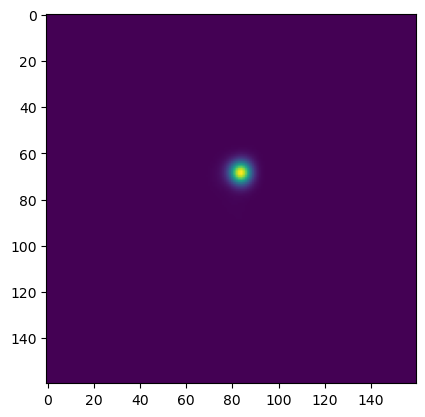

In [370]:
plt.imshow(psfarrs[512])

  0%|          | 0/10000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'log')

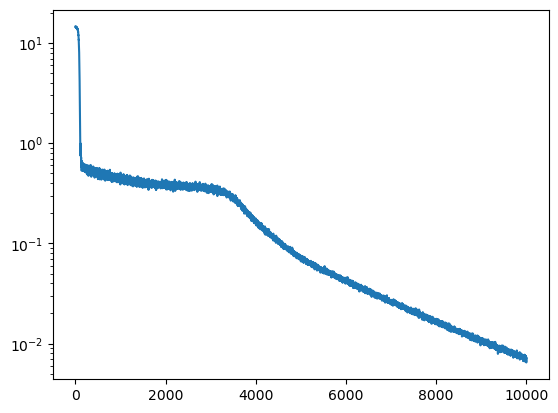

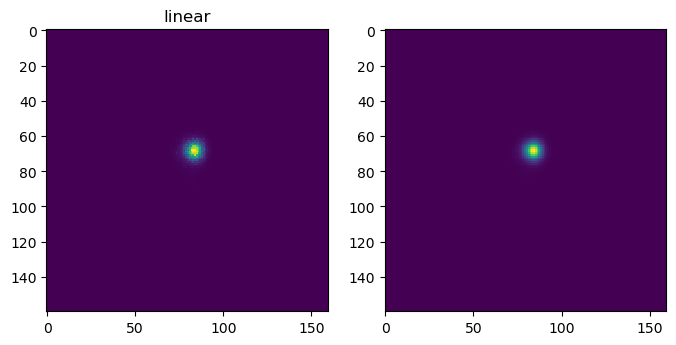

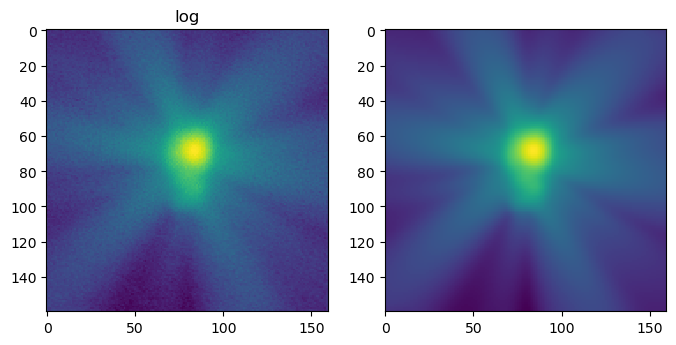

In [372]:
LEARNING_RATE = 1e-4
EPOCHS = 10000
BATCH_SIZE = 2048

psf = psfarrs[512] # psf is (160, 160)

xpx, ypx = jnp.indices(psfarrs.shape[1:])

xs = jnp.stack((xpx.ravel(), ypx.ravel()), axis=-1).astype(float)
xnorm = CoordinateNormalizer(xs)
xs = xnorm.normalize(xs)
ys = psf.ravel()/psf.max()


model = PSFINR(n_in_coo=2, encoder_tau=10, encoder_n_freqs=64, hidden_size=256, num_hidden_layers=4)

optimizer = optax.adam(learning_rate=LEARNING_RATE)

opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses = jnp.ones((EPOCHS,)) * jnp.nan
t = tqdm(range(EPOCHS))
for i in t:
    rkey, subkey = jax.random.split(rkey)
    batch_idx = jax.random.choice(subkey, ys.size, shape=(BATCH_SIZE,), replace=False)
    model, opt_state, loss_value = make_step(model, opt_state, xs[batch_idx], ys[batch_idx], optimizer.update)

    losses = losses.at[i].set(loss_value)
    t.set_postfix({"loss": losses[i]})

plt.semilogy(losses)


pred = jax.vmap(model)(xs).reshape(psfarrs.shape[1:])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 15))
ax1.imshow(pred, interpolation='nearest')
ax2.imshow(psf, interpolation='nearest')
ax1.set_title('linear')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 15))
ax1.imshow(jnp.log(pred), interpolation='nearest')
ax2.imshow(jnp.log(psf), interpolation='nearest')
ax1.set_title('log')

Ok that's the right general idea!  Is it fast enough evaluation?

In [373]:
vm = jax.jit(jax.vmap(model))
vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

%timeit vm(xs).reshape(psfarrs.shape[1:]).block_until_ready()

E0626 16:14:09.690471   25509 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.2 = f32[25600,256]{1,0} fusion(mul.23, constant.30), kind=kCustom, calls=gemm_fusion_dot.2_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"4","output_tiles":[{"sizes":["128","128"]}],"num_ctas":1,"num_stages":4,"is_tma_allowed":true,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0626 16:14:09.690539   25509 xtile_compiler.cc:401] Computation: gemm_fusion_dot.2_computation.clone {
  parameter_0.2 = f32[25600,256]{1,0} parameter(0)
  parameter_1.2 = f32[256,256]{1,0} parameter(1)
  ROOT dot.8 = f32[25600,256]{1,0} dot(parameter_0.2, parameter_1.2), lhs_contracting_dims={1}, rhs_contracting_dims={1}, backend_config={"sizes":["32"]}
}


414 μs ± 5.98 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Oh good plenty fast as long as its pre-jitted.

## Re-formulate for the 4d case

# Non-pairwise version

In [ ]:
class FourierEncoder(eqx.Module):
    freqs: jax.Array

    def __init__(self, n_in_coo, n_freqs, tau, rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)
        rkeys = jax.random.split(rkey, 2)

        self.freqs = jax.random.normal(rkeys[0], (n_freqs, n_in_coo))*tau 

    def __call__(self, coord):
        freqs = jax.lax.stop_gradient(self.freqs)

        # this is the mix-all case, which could work in theory but seems like it doesnt work well for the pairs-of-xys-case
        angles = 2 * jnp.pi * (freqs @ coord)

        sincoos = jnp.sin(angles)  
        coscoos = jnp.cos(angles)

        return jnp.concatenate([sincoos.ravel(), coscoos.ravel()])


class PSFINR(eqx.Module):
    coordinate_encoder: eqx.Module
    mlp: eqx.nn.MLP

    def __init__(self, n_in_coo,
                       hidden_size=128, 
                       num_hidden_layers=3, 
                       activation=jax.nn.gelu,
                       final_mlp_activation=jax.nn.sigmoid,
                       encoder_nfreqs=10,
                       encoder_tau=1.0,
                       rkey=None):
        if rkey is None:
            rkey = jax.random.PRNGKey(0)
        rkeys = jax.random.split(rkey, 2)

        self.coordinate_encoder = FourierEncoder(n_in_coo=n_in_coo, n_freqs=encoder_nfreqs, tau=encoder_tau, rkey=rkeys[0])

        self.mlp = eqx.nn.MLP(in_size=encoder_nfreqs*n_in_coo*2,
                              out_size=1, 
                              depth=num_hidden_layers, 
                              width_size=hidden_size, 
                              activation=activation,
                              final_activation=final_mlp_activation,
                              key=rkeys[1])
        
    def __call__(self, x):
        z = self.coordinate_encoder(x).ravel()
        y = self.mlp(z)
        return y.squeeze()
    
    @property
    def n_in_coo(self):
        return self.mlp.in_size // (self.coordinate_encoder.freqs.shape[0] * 2)
    
model = PSFINR(n_in_coo=4)
print(model)

x = jax.random.uniform(rkey, (10, 4))
jax.vmap(model)(x)